## **0. EDA — Telco Customer Churn**


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data_loader import load_telco

IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

df = load_telco("../data/Telco-Customer-Churn.csv")

## **1. Churn rate — Imbalanced problem**

Churn rate: 26.5% —> imbalanced classification problem


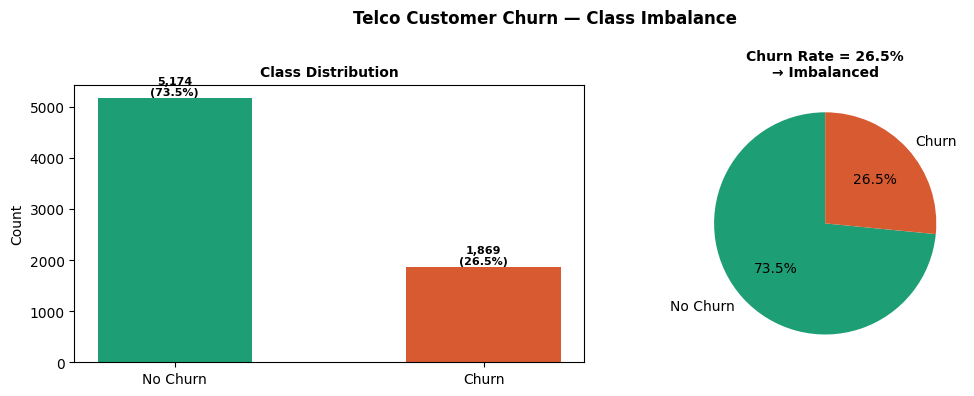

In [2]:
churn_counts = df["Churn"].value_counts()
churn_rate   = df["Churn"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
axes[0].bar(["No Churn", "Churn"], churn_counts.values,
            color=["#1D9E75", "#D85A30"], width=0.5)
for i, (_, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 50, f"{val:,}\n({val/len(df):.1%})",
                 ha="center", fontsize=8, fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Count")

# Pie
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            colors=["#1D9E75", "#D85A30"], autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 10})
axes[1].set_title(f"Churn Rate = {churn_rate:.1%}\n"
                  f"→ Imbalanced", fontsize=10, fontweight="bold")

plt.suptitle("Telco Customer Churn — Class Imbalance", fontsize=12, fontweight="bold")
plt.tight_layout()
print(f"Churn rate: {churn_rate:.1%} —> imbalanced classification problem")
plt.savefig(IMAGES / "churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## **2. Churn by Contract type**

Contract Type Month-to-Month has the highest churn rate = 42.7%


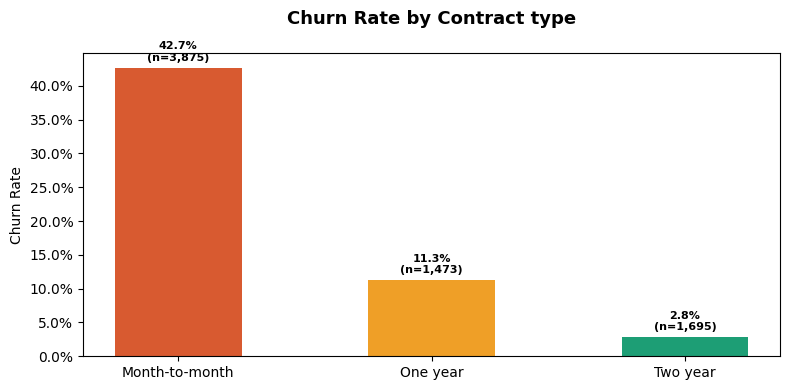

In [8]:
contract_churn = df.groupby("Contract")["Churn"].agg(["mean", "count"]).reset_index()
contract_churn.columns = ["Contract", "Churn Rate", "Count"]
contract_churn = contract_churn.sort_values("Churn Rate", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contract_churn["Contract"], contract_churn["Churn Rate"],
              color=["#D85A30", "#EF9F27", "#1D9E75"], width=0.5)
ax.set_title("Churn Rate by Contract type\n", fontsize=13, fontweight="bold")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, row in zip(bars, contract_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row._2:.1%}\n(n={row.Count:,})", ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()

print(f"Contract Type Month-to-Month has the highest churn rate = {contract_churn['Churn Rate'][0]:.1%}")
plt.savefig(IMAGES / "churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()


## **3. Churn theo Tenure**

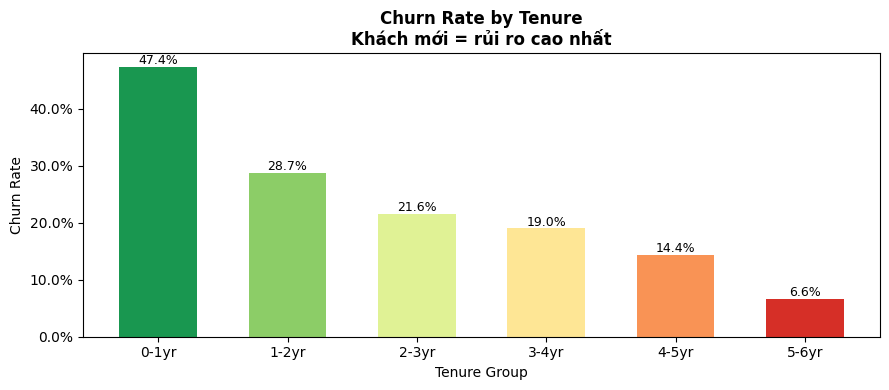

In [9]:
df["tenure_group"] = pd.cut(df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"],
    include_lowest=True)

tenure_churn = df.groupby("tenure_group", observed=True)["Churn"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
colors_t = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tenure_churn)))
bars = ax.bar(tenure_churn.index, tenure_churn.values, color=colors_t, width=0.6)
ax.set_title("Churn Rate by Tenure\nKhách mới = rủi ro cao nhất",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Tenure Group")
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(IMAGES / "churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()


## **4. Numerical features: Churn vs No Churn**

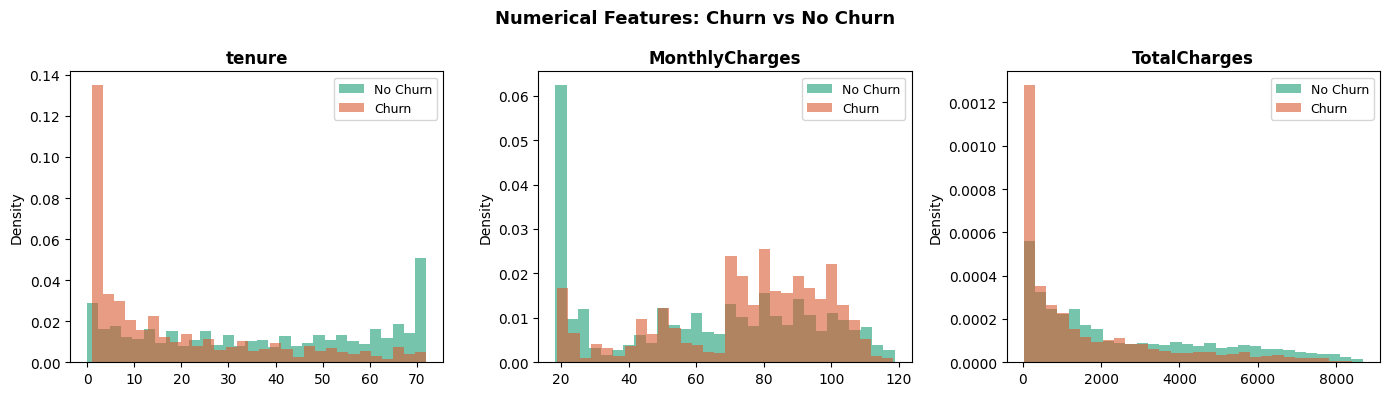

In [5]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    for churn_val, label, color in zip([0, 1], ["No Churn", "Churn"], ["#1D9E75", "#D85A30"]):
        subset = df[df["Churn"] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Numerical Features: Churn vs No Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(IMAGES / "numerical_features_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## **5. Heatmap — Churn rate**

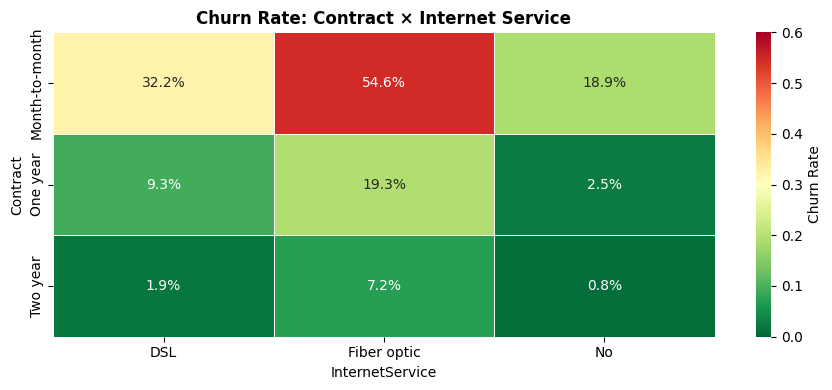

In [6]:
pivot_data = df.groupby(["Contract", "InternetService"])["Churn"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_data, annot=True, fmt=".1%", cmap="RdYlGn_r",
            ax=ax, linewidths=0.5, vmin=0, vmax=0.6,
            cbar_kws={"label": "Churn Rate"})
ax.set_title("Churn Rate: Contract × Internet Service", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES / "churn_heatmap_contract_internet.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Key EDA Insights

In [7]:
print("="*60)
print("KEY INSIGHTS TỪ EDA")
print("="*60)

m2m_churn  = df[df["Contract"] == "Month-to-month"]["Churn"].mean()
fiber_churn = df[df["InternetService"] == "Fiber optic"]["Churn"].mean()
new_churn   = df[df["tenure"] <= 12]["Churn"].mean()
old_churn   = df[df["tenure"] > 48]["Churn"].mean()

print(f"""
1. IMBALANCED: Churn rate = {churn_rate:.1%}
   → Accuracy không phải metric phù hợp
   → Cần: Precision, Recall, F1, AUC-ROC

2. CONTRACT là yếu tố quan trọng nhất:
   Month-to-month churn = {m2m_churn:.1%}
   → Cao hơn gấp nhiều lần Two-year

3. INTERNET SERVICE:
   Fiber optic churn = {fiber_churn:.1%}
   → Có thể do giá cao hoặc chất lượng

4. TENURE:
   Khách mới (0-12 tháng) churn = {new_churn:.1%}
   Khách lâu (>48 tháng) churn  = {old_churn:.1%}
   → Onboarding experience rất quan trọng

5. COMBINATION NGUY HIỂM:
   Month-to-month + Fiber optic → churn cao nhất
   → Target nhóm này cho retention campaign đầu tiên
""")

KEY INSIGHTS TỪ EDA

1. IMBALANCED: Churn rate = 26.5%
   → Accuracy không phải metric phù hợp
   → Cần: Precision, Recall, F1, AUC-ROC

2. CONTRACT là yếu tố quan trọng nhất:
   Month-to-month churn = 42.7%
   → Cao hơn gấp nhiều lần Two-year

3. INTERNET SERVICE:
   Fiber optic churn = 41.9%
   → Có thể do giá cao hoặc chất lượng

4. TENURE:
   Khách mới (0-12 tháng) churn = 47.4%
   Khách lâu (>48 tháng) churn  = 9.5%
   → Onboarding experience rất quan trọng

5. COMBINATION NGUY HIỂM:
   Month-to-month + Fiber optic → churn cao nhất
   → Target nhóm này cho retention campaign đầu tiên

